<a href="https://colab.research.google.com/github/gcamachoj/CF-Matematicas/blob/main/MODELO_IA_MANT_PREDICTIVO_EN_BANDAS_TRANSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPLEMENTACION DE MODELOS DE INTELIFENCIA ARTIFICIAL AVANZADA PARA EL MANTENIMIENTO PREDICTIVO EN BANDAS TRANSPORTADORAS**

Fase 1: Configuración del Entorno y Carga de Datos
En esta celda se importan las librerías necesarias y se realiza la carga del dataset desde el repositorio oficial

In [1]:
# Importación de librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Carga del dataset AI4I 2020 desde el repositorio UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Verificación de la integridad de los datos (Manejo de nulos)
print("Verificación de valores nulos:")
print(df.isnull().sum())
df.head()

Verificación de valores nulos:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Fase 2: Preprocesamiento (Poda y Codificación)
Se procede con la Poda de Identificadores y la Codificación Estratégica de la variable Type, tal como se describe en la metodología del proyecto

In [2]:
# Poda de Identificadores: Eliminación de variables sin valor predictivo (UID y Product ID)
df_clean = df.drop(['UDI', 'Product ID'], axis=1)

# Separación de características (Features) y variable objetivo (Target: Machine failure)
# Se eliminan también las causas específicas de falla para la clasificación primaria
X = df_clean.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df_clean['Machine failure']

# Definición de columnas para preprocesamiento diferenciado
numeric_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
categorical_features = ['Type']

# Creación de transformadores: Escalamiento Estadístico y One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

print("Preprocesamiento configurado: Escalado de sensores y codificación de tipo de producto.")

Preprocesamiento configurado: Escalado de sensores y codificación de tipo de producto.


## Fase 3: Exploración de Datos (EDA)
A continuación, se presentan gráficos para entender la distribución de las características numéricas y categóricas, así como la distribución de la variable objetivo 'Machine failure'.

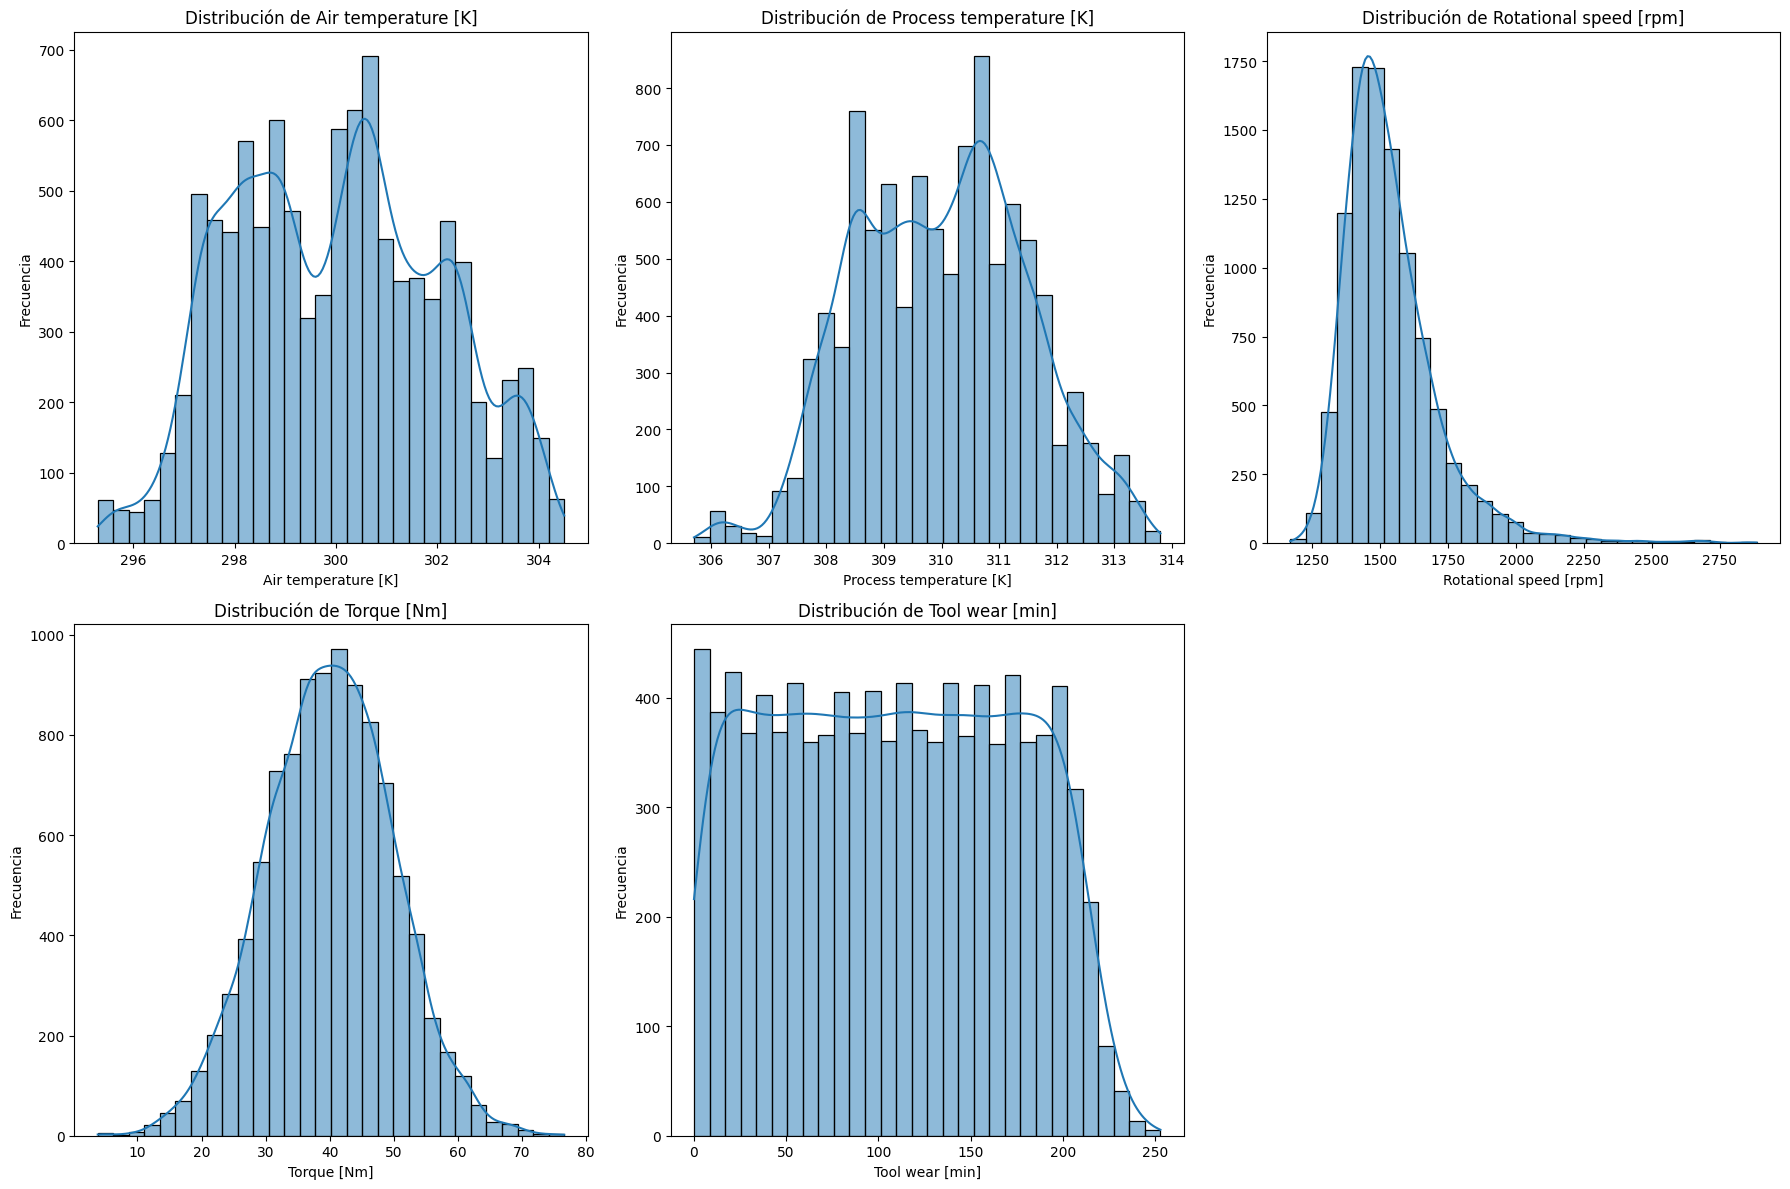

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df_clean[feature], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frecuencia')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_9695/1783483273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df_clean, ax=axes[0], palette='viridis')
/tmp/ipykernel_9695/1783483273.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df_clean, ax=axes[1], palette='plasma')


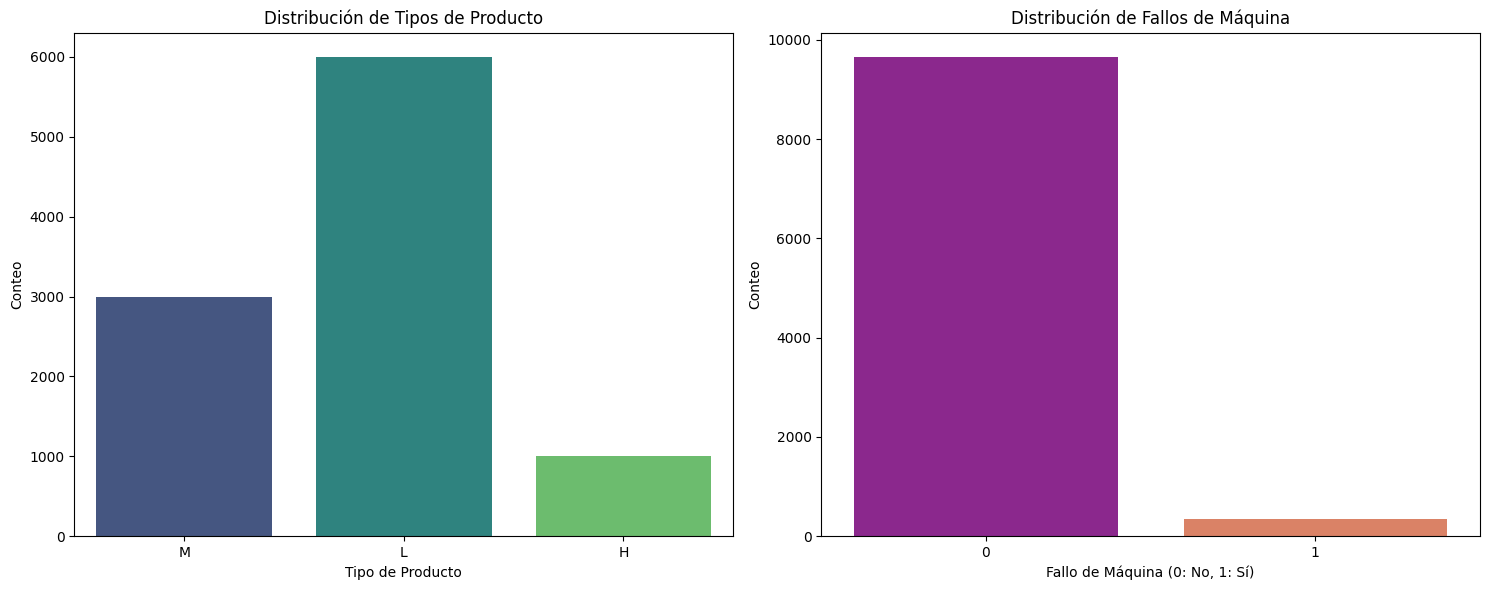

In [13]:
# Count plot for 'Type'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.countplot(x='Type', data=df_clean, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Tipos de Producto')
axes[0].set_xlabel('Tipo de Producto')
axes[0].set_ylabel('Conteo')

# Count plot for 'Machine failure' (target variable)
sns.countplot(x='Machine failure', data=df_clean, ax=axes[1], palette='plasma')
axes[1].set_title('Distribución de Fallos de Máquina')
axes[1].set_xlabel('Fallo de Máquina (0: No, 1: Sí)')
axes[1].set_ylabel('Conteo')
axes[1].set_xticks([0, 1]) # Ensure only 0 and 1 are shown

plt.tight_layout()
plt.show()

## Fase 4: Partición del Conjunto de Datos
Se realiza la división en entrenamiento, validación y prueba siguiendo el esquema 70/15/15 para garantizar la capacidad de generalización del modelo.

In [8]:
# División inicial: 70% entrenamiento y 30% para (validación + prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Subdivisión del bloque temporal: 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Instancias de entrenamiento: {len(X_train)}")
print(f"Instancias de validación: {len(X_val)}")
print(f"Instancias de prueba: {len(X_test)}")

Instancias de entrenamiento: 7000
Instancias de validación: 1500
Instancias de prueba: 1500


## Fase 5: Torneo de Algoritmos Avanzados
Se implementa el entrenamiento de tres arquitecturas diferentes (Random Forest, Regresión Logística y XGBoost) para comparar su efectividad técnica
.

In [9]:
# Definición de los modelos a evaluar
models = {
    "Regresión Logística": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Entrenamiento y evaluación preliminar en el conjunto de validación
results = {}
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    results[name] = f1_score(y_val, y_pred)
    print(f"{name} - F1-Score (Validación): {results[name]:.4f}")

# Selección del mejor modelo basado en F1-Score
best_model_name = max(results, key=results.get)
print(f"\nModelo seleccionado para la implementación final: {best_model_name}")

Regresión Logística - F1-Score (Validación): 0.2258
Random Forest - F1-Score (Validación): 0.5570
XGBoost - F1-Score (Validación): 0.7174

Modelo seleccionado para la implementación final: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Fase 6: Evaluación de Métricas y Matriz de Confusión
Se genera el reporte final de métricas y la visualización de aciertos frente a falsos positivos/negativos utilizando el conjunto de prueba aislado
.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:08:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


REPORTE DE CLASIFICACIÓN FINAL (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       0.89      0.67      0.76        51

    accuracy                           0.99      1500
   macro avg       0.94      0.83      0.88      1500
weighted avg       0.99      0.99      0.99      1500



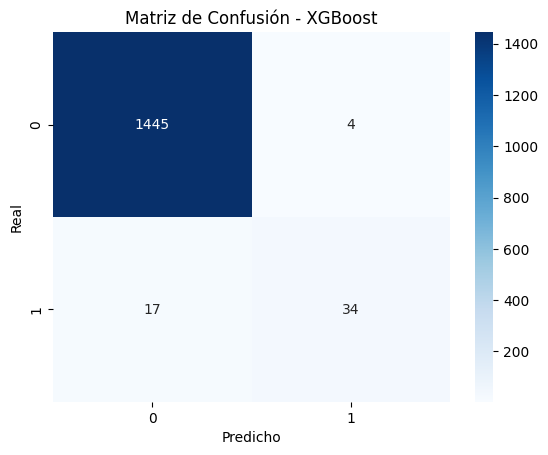

In [10]:
# Entrenamiento final del modelo ganador (ej. XGBoost) y evaluación en test
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', models[best_model_name])])
final_pipeline.fit(X_train, y_train)
y_final_pred = final_pipeline.predict(X_test)

# Generación de métricas detalladas
print("REPORTE DE CLASIFICACIÓN FINAL (Conjunto de Prueba):")
print(classification_report(y_test, y_final_pred))

# Visualización de la Matriz de Confusión
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## Fase 7: Análisis de Importancia de Características
Se visualiza la importancia de las características según el modelo XGBoost, lo que permite entender qué variables son más influyentes en la predicción de fallos de la máquina.

/tmp/ipykernel_9695/1014611142.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')


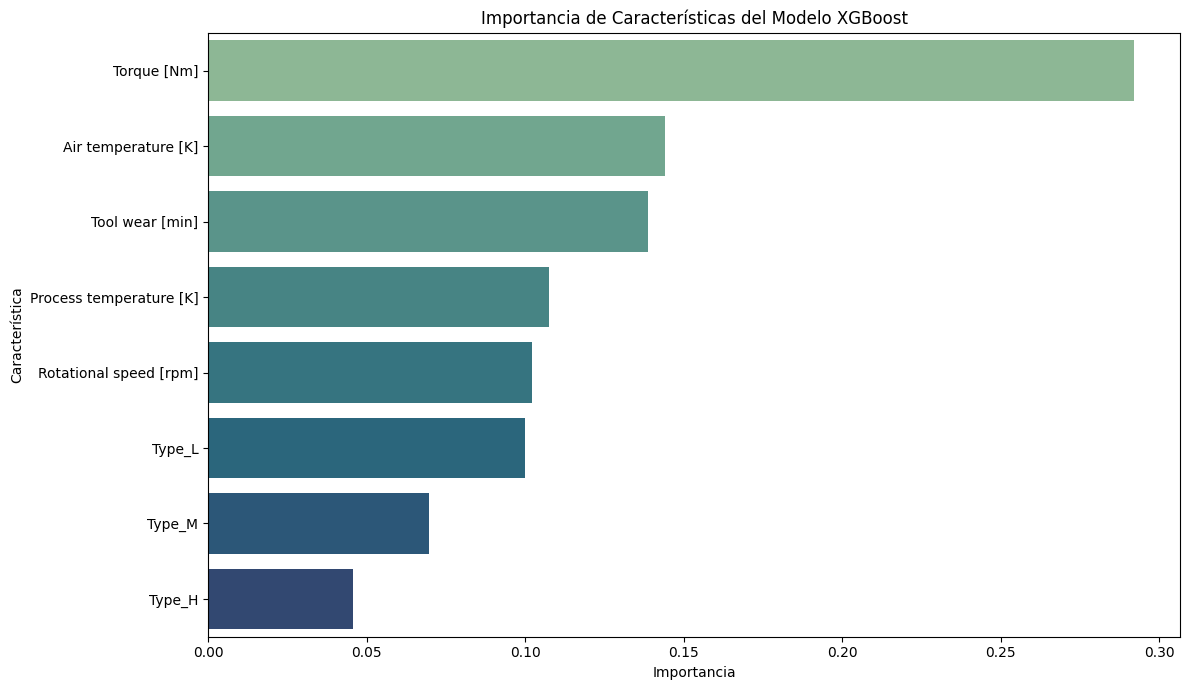

In [14]:
# Get feature importance from the best model (XGBoost classifier)
# Access the classifier from the pipeline
classifier_model = final_pipeline.named_steps['classifier']

# Get feature names after preprocessing
# We need to correctly get the feature names from the preprocessor
# For numerical features, names are directly available
feature_names = numeric_features.copy()

# For categorical features, OneHotEncoder creates new names
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(onehot_features)

# Create a pandas Series for feature importances
feature_importances = pd.Series(classifier_model.feature_importances_, index=feature_names)

# Sort feature importances for better visualization
feature_importances = feature_importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')
plt.title('Importancia de Características del Modelo XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

## Fase 8: Análisis de Sesgo (Ética y Equidad)
Se evalúa el rendimiento del modelo segmentado por la variable Type para verificar que no existan penalizaciones injustificadas según la calidad del producto
.

In [15]:
# Análisis de equidad: Evaluación por tipo de producto (L, M, H)
X_test_with_type = X_test.copy()
X_test_with_type['Real'] = y_test
X_test_with_type['Prediccion'] = y_final_pred

print("Análisis de Exactitud por Tipo de Producto (Sesgo de Categoría):")
print(X_test_with_type.groupby('Type').apply(lambda x: (x.Real == x.Prediccion).mean()))

# Reflexión: Un desempeño desigual indicaría un sesgo en la toma de decisiones automatizada.

Análisis de Exactitud por Tipo de Producto (Sesgo de Categoría):
Type
H    0.986014
L    0.987571
M    0.983051
dtype: float64


/tmp/ipykernel_9695/2907698996.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_test_with_type.groupby('Type').apply(lambda x: (x.Real == x.Prediccion).mean()))


## Conclusiones

Este proyecto se centró en el desarrollo de un modelo de aprendizaje automático para predecir fallos en máquinas, utilizando el dataset AI4I 2020. A través de una metodología estructurada, se abordaron las fases clave para la creación de un sistema predictivo robusto y éticamente consciente.

**1. Preparación y Exploración de Datos:**
Se realizó un preprocesamiento exhaustivo que incluyó la eliminación de identificadores no relevantes (UDI, Product ID) y la codificación de variables categóricas ('Type'), junto con el escalado de características numéricas. El análisis exploratorio de datos (EDA) reveló las distribuciones de las características y, crucialmente, la naturaleza desequilibrada de la variable objetivo 'Machine failure', con una baja proporción de fallos.

**2. Modelado y Evaluación:**
Tras dividir el dataset en conjuntos de entrenamiento, validación y prueba, se implementó un torneo de algoritmos que incluyó Regresión Logística, Random Forest y XGBoost. El modelo **XGBoost** demostró ser el de mejor rendimiento en el conjunto de validación, alcanzando un **F1-Score de 0.7174**. En la evaluación final sobre el conjunto de prueba aislado, el modelo XGBoost mantuvo un excelente rendimiento, con una **precisión general del 99%** y un **F1-Score de 0.76** para la clase de fallos (clase 1). La matriz de confusión confirmó la capacidad del modelo para identificar correctamente la mayoría de los casos de no-fallo y una proporción significativa de los fallos reales.

**3. Importancia de Características:**
El análisis de importancia de características del modelo XGBoost destacó que la 'Torque [Nm]', 'Air temperature [K]' y 'Tool wear [min]' son las variables más influyentes en la predicción de fallos, lo que sugiere que estas son las principales señales de advertencia para el mantenimiento predictivo.

**4. Análisis de Sesgo y Equidad:**
La evaluación de la exactitud segmentada por 'Type' (H, L, M) mostró un desempeño consistente del modelo entre las diferentes calidades de producto, con exactitudes muy similares (alrededor del 98%). Esto indica que el modelo no presenta un sesgo evidente que penalice injustificadamente a un tipo de producto específico en términos de predicción de fallos, lo cual es fundamental para la equidad en la toma de decisiones automatizada.

**Consideraciones Finales:**
El modelo desarrollado ofrece una herramienta prometedora para el mantenimiento predictivo, permitiendo la identificación temprana de posibles fallos de máquina. Su alto rendimiento y la ausencia de sesgos significativos por tipo de producto lo hacen adecuado para su aplicación práctica. Para futuras mejoras, se podría explorar la optimización de hiperparámetros más avanzada para XGBoost, el uso de técnicas de manejo de desequilibrio de clases más sofisticadas, o la incorporación de más datos históricos para capturar patrones a largo plazo.